# Linear Economy Estimation **(SVAR)**

Please note that this notebook uses a venv which points to a base python version of **3.13**, some functionality may be limited if using an older version of python

## All Imports

Libraries used:

- Vanilla Modules:
    - typing (optional)
        - just for static type checking and code hygeine, not functionally required.
    - dataclasses (optional)
        - class type of choice for SVAR return object, also not necessary but functionally optimal.
    - datetime
        - Used for datetime.now() to set the end date bound for out of sample data.
    
- 3rd party:
    - fedfred
        - This is the library which I wrote, published, and currently maintain under the MIT License
        - Makes API requests to the FRED database and returns strongly typed and structured objects as well as dataframes to reduce boilerplate code.
    - pandas
        - dataframe backend of choice, if computational speed or parallalelization becomes a necessity the fedfred backend accomodates dask and polars.
    - numpy
        - for mathematical ops and pandas interop
    - statsmodels
        - for OLS and potentially VAR model if necessary.
    - matplotlib
        - Used for plotting results.

In [230]:
%pip install fedfred pandas numpy statsmodels matplotlib ipympl ipywidgets jupyterlab-lsp nbdime --quiet


[notice] A new release of pip is available: 25.3 -> 26.0
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [231]:
import fedfred as fed
import pandas as pd
import numpy as np
from typing import Union, Tuple, Dict, List, Any
from dataclasses import dataclass
import statsmodels.api as sm
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.diagnostic import acorr_breusch_godfrey
import datetime
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

In [232]:
%matplotlib widget

## Model Assumptions and Static Inputs

According to the paper static inputs are as follows:

- training data is bound from 1987 Q3 to 2007 Q2 
    - we can update these values for recency, if we want to be predictive, or leave them if we want to compare recent interest rate decisions with predictive outputs

- all data used is quarterly as specified by the paper.

In [233]:
# Training data Time Period: Q3 1987 - Q2 2007
start_date = "1987-07-01"
end_date = "2007-06-30"

# Training data Observation Frequency
freq = "q"  # Quarterly

# Fred client
fred = fed.FredAPI(api_key="7ab121fb17773e187bb6508e83e411da", cache_mode=True, cache_size=256)

## Data Helpers

### Pandas Dataframe to Series Conversion Function

Simple function for converting `pandas.DataFrames` of the standard return format for `fedfred.FredAPI.get_series_observations` to a `pandas.Series`

In [234]:
def to_series(x: Union[pd.Series, pd.DataFrame], name: str) -> pd.Series:
    """
    Accepts a Series or a DataFrame with 'date'/'value' columns (fedfred style) and returns a float Series with DatetimeIndex and the given `name`.

    Args:
        x (pd.Series | pd.DataFrame): Input data to be converted.
        name (str): Name to assign to the resulting Series.

    Returns:
        pd.Series: A float Series with DatetimeIndex and the given `name`.

    Raises:
        TypeError: If the input is neither a pd.Series nor a pd.DataFrame. 
    """
    if isinstance(x, pd.Series):
        s = x.copy()
        s.index = pd.to_datetime(s.index)
        s = s.astype(float)
        s.name = name
        return s

    if not isinstance(x, pd.DataFrame):
        raise TypeError("Input must be a pd.Series or pd.DataFrame")

    df = x.copy()

    # 1) Identify the datetime index/column
    if df.index.name and df.index.name.lower() == "date":
        idx = pd.to_datetime(df.index)
    elif "date" in df.columns:
        idx = pd.to_datetime(df["date"])
    else:
        # try any column with 'date' in the name
        cand = next((c for c in df.columns if "date" in c.lower()), None)
        if cand is not None:
            idx = pd.to_datetime(df[cand])
        else:
            # last resort: try to_datetime on the current index
            idx = pd.to_datetime(df.index)

    # 2) Identify the value column (prefer 'value', else first numeric)
    if "value" in df.columns:
        vals = pd.to_numeric(df["value"], errors="coerce")
    else:
        num_cols = [c for c in df.columns if np.issubdtype(df[c].dtype, np.number)]
        if not num_cols:
            # take the last column and coerce
            vals = pd.to_numeric(df.iloc[:, -1], errors="coerce")
        else:
            vals = pd.to_numeric(df[num_cols[0]], errors="coerce")

    s = pd.Series(vals.values, index=idx, name=name).astype(float)
    # Clean up: sort, dedupe, and ensure DatetimeIndex
    s = s[~s.index.duplicated(keep="last")].sort_index()
    s.index = pd.to_datetime(s.index)
    return s

## Data Retrieval and Preparation

### Data Fetching

- $\pi_t$ -> Quarterly Inflationary Metric (YoY%)
    - For our inflationary measure we use the **GDP: Implicit Price Deflator** as specified in the paper.
    - FRED Series ID: **GDPDEF**
- $Y_{t}$ -> Quarterly Real Output
    - For our real production output metric we use **Real GDP**
    - FRED Series ID: **GDPC1**
- $Y_{t}^{\ast}$ -> Quarterly Potential Output
    - For our potential production output metric we use **Potential GDP**
    - FRED Series ID: **GDPPOT**
- $i_{t}$ -> Quarterly Interest Rate
    - For our interest rate metric we us **Effective Federal Funds Rate**
    - FRED Series ID: **FEDFUNDS**

In [235]:
# Fetch data from FRED
gdpdef_yoy = fred.get_series_observations(
    series_id="GDPDEF",
    observation_start=start_date,
    observation_end=end_date,
    frequency=freq,
    units="pc1" # YoY percent change
)

real_gdp = fred.get_series_observations(
    series_id="GDPC1",
    observation_start=start_date,
    observation_end=end_date,
    frequency=freq,
    units="lin" # Linear units (level)
)

potential_gdp = fred.get_series_observations(
    series_id="GDPPOT",
    observation_start=start_date,
    observation_end=end_date,
    frequency=freq,
    units="lin" # Linear units (level)
)

effective_ffr = fred.get_series_observations(
    series_id="FEDFUNDS",
    observation_start=start_date,
    observation_end=end_date,
    frequency=freq,
    aggregation_method="avg" # Aggregate daily data to quarterly by averaging (specificly important for interest rates)
)

# Check data
print(gdpdef_yoy.head())
print(real_gdp.head())
print(potential_gdp.head())
print(effective_ffr.head())

           realtime_start realtime_end    value
date                                           
1987-07-01     2026-01-22   2026-01-22  2.66122
1987-10-01     2026-01-22   2026-01-22  2.91876
1988-01-01     2026-01-22   2026-01-22  3.06577
1988-04-01     2026-01-22   2026-01-22  3.35274
1988-07-01     2026-01-22   2026-01-22  3.80207
           realtime_start realtime_end     value
date                                            
1987-07-01     2026-01-22   2026-01-22  9162.024
1987-10-01     2026-01-22   2026-01-22  9319.332
1988-01-01     2026-01-22   2026-01-22  9367.502
1988-04-01     2026-01-22   2026-01-22  9490.594
1988-07-01     2026-01-22   2026-01-22  9546.206
           realtime_start realtime_end        value
date                                               
1987-07-01     2026-01-21   2026-01-21  9197.770225
1987-10-01     2026-01-21   2026-01-21  9270.501462
1988-01-01     2026-01-21   2026-01-21  9343.141538
1988-04-01     2026-01-21   2026-01-21  9416.313106
1988-07-0

### Series Construction

In [236]:
# Convert to Series with proper names
pi = to_series(gdpdef_yoy, "pi")
y_real = to_series(real_gdp, "y_real")
y_pot = to_series(potential_gdp, "y_pot")
i = to_series(effective_ffr, "i")

# Check converted data
print(pi.head())
print(y_real.head())
print(y_pot.head())
print(i.head())

date
1987-07-01    2.66122
1987-10-01    2.91876
1988-01-01    3.06577
1988-04-01    3.35274
1988-07-01    3.80207
Name: pi, dtype: float64
date
1987-07-01    9162.024
1987-10-01    9319.332
1988-01-01    9367.502
1988-04-01    9490.594
1988-07-01    9546.206
Name: y_real, dtype: float64
date
1987-07-01    9197.770225
1987-10-01    9270.501462
1988-01-01    9343.141538
1988-04-01    9416.313106
1988-07-01    9489.692044
Name: y_pot, dtype: float64
date
1987-07-01    6.84
1987-10-01    6.92
1988-01-01    6.66
1988-04-01    7.16
1988-07-01    7.98
Name: i, dtype: float64


#### YoY Inflation in % using log-difference over 4 quarters: 
$\pi_t = 100 \times \left(\frac{P_t}{P_{t-4}} - 1\right)$

We don't need to calculate this as FRED made the transformation for us when we specified the `units="pc1"` arg.

In [237]:
# Double check var assignment
print(pi.head())
print(pi.tail())

date
1987-07-01    2.66122
1987-10-01    2.91876
1988-01-01    3.06577
1988-04-01    3.35274
1988-07-01    3.80207
Name: pi, dtype: float64
date
2006-04-01    3.35642
2006-07-01    3.13805
2006-10-01    2.66316
2007-01-01    2.91019
2007-04-01    2.72883
Name: pi, dtype: float64


#### Output Gap Percent Deviation:

$y_t = 100 \times \left(\frac{Y_t}{Y_t^\ast} - 1\right)$

In [238]:
y_gap = 100.0 * (y_real / y_pot - 1.0)
y_gap.name = "y"

# Check calculated series
print(y_gap.head())
print(y_gap.tail())

date
1987-07-01   -0.388640
1987-10-01    0.526730
1988-01-01    0.260731
1988-04-01    0.788853
1988-07-01    0.595530
Name: y, dtype: float64
date
2006-04-01    1.319357
2006-07-01    0.978513
2006-10-01    1.380249
2007-01-01    1.210046
2007-04-01    1.336951
Name: y, dtype: float64


#### Policy Rate:
${i_t}$

In [239]:
# Double check var assignment
print(i.head())
print(i.tail())

date
1987-07-01    6.84
1987-10-01    6.92
1988-01-01    6.66
1988-04-01    7.16
1988-07-01    7.98
Name: i, dtype: float64
date
2006-04-01    4.91
2006-07-01    5.25
2006-10-01    5.25
2007-01-01    5.26
2007-04-01    5.25
Name: i, dtype: float64


#### Merge and Check

In [240]:
# Merge
df = pd.concat([pi, y_gap, i], axis=1).dropna()
df.index = pd.PeriodIndex(df.index, freq="Q") # Use a quarterly PeriodIndex

# Check
print(df.head())
print(df.tail())
print(df.index.min(), "→", df.index.max())

# Additional Sanity Check:
assert df.index.min() == pd.Period("1987Q3", "Q")
assert df.index.max() == pd.Period("2007Q2", "Q")
assert len(df) == 80
assert not df.isna().any().any()

             pi         y     i
date                           
1987Q3  2.66122 -0.388640  6.84
1987Q4  2.91876  0.526730  6.92
1988Q1  3.06577  0.260731  6.66
1988Q2  3.35274  0.788853  7.16
1988Q3  3.80207  0.595530  7.98
             pi         y     i
date                           
2006Q2  3.35642  1.319357  4.91
2006Q3  3.13805  0.978513  5.25
2006Q4  2.66316  1.380249  5.25
2007Q1  2.91019  1.210046  5.26
2007Q2  2.72883  1.336951  5.25
1987Q3 → 2007Q2


## Linear SVAR Environment Estimation

## Fitting Helpers

### SVAR Return Object

Return object for SVAR Function (OLS) is simply a python `dataclasses.dataclass` containing `statsmodels.api.regression.linear_model.RegressionResultsWrapper`, `pandas.DataFrame`, and `pandas.Series` as instance attributes.

In [241]:
@dataclass(frozen=True)
class _ResultsView:
    """
    Wrapper for a *restricted/refit* statsmodels result that:
    - delegates diagnostics/predict/summary to the restricted refit
    - exposes `.params`/`.pvalues` as "table-safe" Series that also include dropped terms
      (dropped terms show coef=0.0; pvalue is taken from the full model used for the drop decision)
    """
    _res_restricted: sm.regression.linear_model.RegressionResultsWrapper
    _params_table: pd.Series
    _pvalues_table: pd.Series

    @property
    def params(self) -> pd.Series:
        return self._params_table

    @property
    def pvalues(self) -> pd.Series:
        return self._pvalues_table

    def __getattr__(self, name):
        return getattr(self._res_restricted, name)


@dataclass(frozen=True)
class SVARResults:
    _mod_y_full: sm.regression.linear_model.RegressionResultsWrapper
    _mod_pi_full: sm.regression.linear_model.RegressionResultsWrapper
    _mod_y_restricted: sm.regression.linear_model.RegressionResultsWrapper
    _mod_pi_restricted: sm.regression.linear_model.RegressionResultsWrapper

    X_y: pd.DataFrame          # restricted design matrix (used for predict)
    X_pi: pd.DataFrame         # restricted design matrix (used for predict)
    resid_y: pd.Series
    resid_pi: pd.Series

    # table-safe (includes dropped terms as 0.0)
    coef_y: Dict[str, float]
    coef_pi: Dict[str, float]
    pvalues_y: Dict[str, float]
    pvalues_pi: Dict[str, float]

    zeroed_y: List[str]  # dropped in refit
    zeroed_pi: List[str] # dropped in refit

    @property
    def mod_y(self) -> _ResultsView:
        return _ResultsView(
            self._mod_y_restricted,
            pd.Series(self.coef_y),
            pd.Series(self.pvalues_y),
        )

    @property
    def mod_pi(self) -> _ResultsView:
        return _ResultsView(
            self._mod_pi_restricted,
            pd.Series(self.coef_pi),
            pd.Series(self.pvalues_pi),
        )

        

### SVAR Lag Dropping Function

As per the paper after performing recursive SVAR(2) via OLS we drop all lags that are insignificant (${p>{\alpha}}$ for ${\alpha}=0.10$)

In [242]:
def identify_insignificant_lag2_terms(
    model: sm.regression.linear_model.RegressionResultsWrapper,
    *,
    alpha: float = 0.10,
    suffix: str = "_lag2",
) -> List[str]:
    """Return list of lag2 regressor names with p-value > alpha."""
    drop: List[str] = []
    for k in model.params.index:
        if k.endswith(suffix) and k in model.pvalues.index and float(model.pvalues[k]) > alpha:
            drop.append(k)
    return drop

### SVAR Fitting Function

The recursively fit SVAR function is done using `statsmodels.api.OLS` (Ordinary Least Squares) as specified in the paper, in order to create the linear environment. The linear economy is represented using ${\hat{f}^m = {C}^m + {\alpha}^{m'}{s_t^m}}$ where ${\hat{f}^m}$ represents a linear function comprised of the collected inputs from the ${s_t^m}$ vector. ${C^m}$ and ${a^m}$ for ${m}{\in}$ {${pi}$, ${y}$} are the constant and vector coefficients. If we expand ${s_t^{m}}$ for $m{\in}$ {${\pi,y}$} we get the input vectors for a standard SVAR(2) specification: ${{s_t^y} = (y_{t-1}, y_{t-2}, {\pi_{t-1}}, {\pi_{t-2}} {i_{t-1}}, {i_{t-2}})}$ and ${{s_t^{\pi}} = (y_t ,y_{t-1}, y_{t-2}, {\pi_{t-1}}, {\pi_{t-2}}, {i_{t-1}}, {i_{t-2}})}$. It is important to note that the only vector which relies on a contemporaneous term is ${s_t^{\pi}}$ which contains contemporaneous ${y_t}$. The following step is to recursively fit the OLS with a lag drop parameter of 10% to get our reduced spec VAR.

In [243]:
def fit_linear_svar(df: pd.DataFrame, alpha_drop: float = 0.10) -> SVARResults:
    """
    Paper-aligned procedure:
    1) fit full SVAR(2) OLS
    2) drop insignificant *_lag2 terms (p > alpha_drop) based on the full fit
    3) refit the restricted model without those regressors
    """
    assert {"pi", "y", "i"}.issubset(df.columns), "df must have columns: 'pi', 'y', 'i'"

    work = df.copy().sort_index()
    for c in ("pi", "y", "i"):
        work[f"{c}_lag1"] = work[c].shift(1)
        work[f"{c}_lag2"] = work[c].shift(2)

    # ---- y equation (FULL) ----
    y_target = work["y"]
    X_y_full = work[["y_lag1", "y_lag2", "pi_lag1", "pi_lag2", "i_lag1", "i_lag2"]]
    X_y_full = sm.add_constant(X_y_full, has_constant="add")
    ymask = X_y_full.notna().all(axis=1) & y_target.notna()
    X_y_full = X_y_full.loc[ymask]
    y_target = y_target.loc[ymask]

    mod_y_full = sm.OLS(y_target, X_y_full).fit()
    drop_y = identify_insignificant_lag2_terms(mod_y_full, alpha=alpha_drop)

    # ---- y equation (RESTRICTED refit) ----
    X_y_res = X_y_full.drop(columns=drop_y, errors="ignore")
    mod_y_res = sm.OLS(y_target, X_y_res).fit()

    # ---- pi equation (FULL) ----
    pi_target = work["pi"]
    X_pi_full = work[["y", "y_lag1", "y_lag2", "pi_lag1", "pi_lag2", "i_lag1", "i_lag2"]]
    X_pi_full = sm.add_constant(X_pi_full, has_constant="add")
    pimask = X_pi_full.notna().all(axis=1) & pi_target.notna()
    X_pi_full = X_pi_full.loc[pimask]
    pi_target = pi_target.loc[pimask]

    mod_pi_full = sm.OLS(pi_target, X_pi_full).fit()
    drop_pi = identify_insignificant_lag2_terms(mod_pi_full, alpha=alpha_drop)

    # ---- pi equation (RESTRICTED refit) ----
    X_pi_res = X_pi_full.drop(columns=drop_pi, errors="ignore")
    mod_pi_res = sm.OLS(pi_target, X_pi_res).fit()

    # Residuals from restricted refits
    resid_y = (y_target - mod_y_res.predict(X_y_res)).rename("eps_y")
    resid_pi = (pi_target - mod_pi_res.predict(X_pi_res)).rename("eps_pi")

    # ---- Build "table-safe" params/pvalues that still include dropped terms ----
    # (so your Table 9 indexing doesn't KeyError)
    keys_y = list(X_y_full.columns)
    params_y_tbl = mod_y_res.params.reindex(keys_y, fill_value=0.0)
    pvals_y_tbl = mod_y_res.pvalues.reindex(keys_y)
    for k in drop_y:
        params_y_tbl.loc[k] = 0.0
        pvals_y_tbl.loc[k] = float(mod_y_full.pvalues.get(k, np.nan))

    keys_pi = list(X_pi_full.columns)
    params_pi_tbl = mod_pi_res.params.reindex(keys_pi, fill_value=0.0)
    pvals_pi_tbl = mod_pi_res.pvalues.reindex(keys_pi)
    for k in drop_pi:
        params_pi_tbl.loc[k] = 0.0
        pvals_pi_tbl.loc[k] = float(mod_pi_full.pvalues.get(k, np.nan))

    return SVARResults(
        _mod_y_full=mod_y_full,
        _mod_pi_full=mod_pi_full,
        _mod_y_restricted=mod_y_res,
        _mod_pi_restricted=mod_pi_res,
        X_y=X_y_res,
        X_pi=X_pi_res,
        resid_y=resid_y,
        resid_pi=resid_pi,
        coef_y=params_y_tbl.to_dict(),
        coef_pi=params_pi_tbl.to_dict(),
        pvalues_y=pvals_y_tbl.to_dict(),
        pvalues_pi=pvals_pi_tbl.to_dict(),
        zeroed_y=drop_y,
        zeroed_pi=drop_pi,
    )

In [244]:
# Fit SVAR
svar = fit_linear_svar(df)

print("\n=== Output gap equation ===")
print(svar.mod_y.summary())
print("\n=== Inflation equation ===")
print(svar.mod_pi.summary())

# Sanity Checks:
print("\nResidual std (y, pi):", svar.resid_y.std().round(3), svar.resid_pi.std().round(3))
print("Samples used (y, pi):", svar.mod_y.nobs, svar.mod_pi.nobs)


=== Output gap equation ===
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.884
Model:                            OLS   Adj. R-squared:                  0.880
Method:                 Least Squares   F-statistic:                     188.5
Date:                Wed, 04 Feb 2026   Prob (F-statistic):           1.44e-34
Time:                        14:49:39   Log-Likelihood:                -51.656
No. Observations:                  78   AIC:                             111.3
Df Residuals:                      74   BIC:                             120.7
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.3363  

In [245]:
# sanity check: recursive lag zero
for k, v in svar.mod_y.params.items():
    print(k, v)

for k, v in svar.mod_pi.params.items():
    print(k, v)

for k,v in svar.mod_y.pvalues.items():
    print(k, v)

for k,v in svar.mod_pi.pvalues.items():
    print(k, v)

print("Zeroed in y eq:", svar.zeroed_y)
print("Zeroed in pi eq:", svar.zeroed_pi)

const 0.3363196500557133
y_lag1 0.9881596459612629
y_lag2 0.0
pi_lag1 -0.015720963723518062
pi_lag2 0.0
i_lag1 -0.05968392220776569
i_lag2 0.0
const 0.1177914572556481
y -0.07121124172691162
y_lag1 0.20920010994276494
y_lag2 -0.11098851396690401
pi_lag1 1.3027237438029613
pi_lag2 -0.3244950260921206
i_lag1 -0.014595351623496101
i_lag2 0.0
const 0.06982909394353108
y_lag1 8.857358506908984e-32
y_lag2 0.5362162134349479
pi_lag1 0.8511025990159024
pi_lag2 0.5747995222904049
i_lag1 0.0987343710478478
i_lag2 0.11782749479885529
const 0.11662292504910915
y 0.12086122376162542
y_lag1 0.002362952843835911
y_lag2 0.0209612390416639
pi_lag1 2.7363074745736663e-19
pi_lag2 0.004419046702243066
i_lag1 0.3460091559172036
i_lag2 0.18737592867222724
Zeroed in y eq: ['y_lag2', 'pi_lag2', 'i_lag2']
Zeroed in pi eq: ['i_lag2']


### Reduced SVAR Series Equations:

Output gap equation:

$$
y_t
= C^y
+ \alpha_{y,1}^y\,y_{t-1}
+ \alpha_{\pi,1}^y\,\pi_{t-1}
+ \alpha_{i,1}^y\,i_{t-1}
+ \varepsilon_t^y
$$

Inflation equation (note the contemporaneous ${y_t}$ term):

$$
\pi_t
= C^\pi
+ \alpha_{y,0}^\pi\,y_t
+ \alpha_{y,1}^\pi\,y_{t-1}
+ \alpha_{y,2}^\pi\,y_{t-2}
+ \alpha_{\pi,1}^\pi\,\pi_{t-1}
+ \alpha_{\pi,2}^\pi\,\pi_{t-2}
+ \alpha_{i,1}^\pi\,i_{t-1}
+ \varepsilon_t^\pi
$$

If we substitute our input vectors for the linear environment we arrive at the linear system as follows: ${{y_t} = {C^y} + {{\alpha}_{y,1}^y}{y_{t-1}} + {{\alpha}_{{\pi},1}^y}{{\pi}_{t-1}} + {{\alpha}_{i,1}^y}{i_{t-1}} + {{\alpha}_{i,2}^y}{i_{t-2}} + {\epsilon}_t^y}$ and ${{{\pi}_t} = {C^{\pi}} + {{\alpha}_{y,0}^{\pi}}{y_t} + {{\alpha}_{y,1}^{\pi}}{y_{t-1}} + {{\alpha}_{y,2}^{\pi}}{y_{t-2}} + {{\alpha}_{{\pi},1}^{\pi}}{{\pi}_{t-1}} + {{\alpha}_{{\pi},2}^{\pi}}{{\pi}_{t-2}} + {{\alpha}_{i,1}^{\pi}}{i_{t-1}} + {\epsilon}_t^{\pi}}$ which can be vizualised as:

$$
{\hat{f}^m = {C}^m + {\alpha}^{m'}{s_t^m}}, {m}{\in}{\{ \pi, y \}} =
$$

$$
\begin{cases}
  {C^y} + {{\alpha}_{y,1}^y}{y_{t-1}} + {{\alpha}_{{\pi},1}^y}{{\pi}_{t-1}} + {{\alpha}_{i,1}^y}{i_{t-1}} + {\epsilon}_t^y & m = y \\
  {C^{\pi}} + {{\alpha}_{y,0}^{\pi}}{y_t} + {{\alpha}_{y,1}^{\pi}}{y_{t-1}} + {{\alpha}_{y,2}^{\pi}}{y_{t-2}} + {{\alpha}_{{\pi},1}^{\pi}}{{\pi}_{t-1}} + {{\alpha}_{{\pi},2}^{\pi}}{{\pi}_{t-2}} + {{\alpha}_{i,1}^{\pi}}{i_{t-1}} + {\epsilon}_t^{\pi} & m = \pi
\end{cases}
$$

### Complete Equations with Substituted Coefficients

In [246]:
# Output Gap Components
const_str_y = {
    "string": f"{svar.mod_y.params['const']:.4f}", 
    "val": svar.mod_y.params['const']
    }

y_t1_str_y = {
    "string": f"{svar.mod_y.params['y_lag1']:.4f}y_{{t-1}}",
    "val": svar.mod_y.params['y_lag1']
    }

y_t2_str_y = {
    "string": f"{svar.mod_y.params['y_lag2']:.4f}y_{{t-2}}",
    "val": svar.mod_y.params['y_lag2']
    }

pi_t1_str_y = {
    "string": f"{svar.mod_y.params['pi_lag1']:.4f}{{\pi}}_{{t-1}}",
    "val": svar.mod_y.params['pi_lag1']
    }

pi_t2_str_y = {
    "string": f"{svar.mod_y.params['pi_lag2']:.4f}{{\pi}}_{{t-2}}",
    "val": svar.mod_y.params['pi_lag2']
    }

i_t1_str_y = {
    "string": f"{svar.mod_y.params['i_lag1']:.4f}i_{{t-1}}",
    "val": svar.mod_y.params['i_lag1']
    }

i_t2_str_y = {
    "string": f"{svar.mod_y.params['i_lag2']:.4f}i_{{t-2}}",
    "val": svar.mod_y.params['i_lag2']
    }

# Inflation Components
const_str_pi = {
    "string": f"{svar.mod_pi.params['const']:.4f}",
    "val": svar.mod_pi.params['const']
    }

y_t0_str_pi = {
    "string": f"{svar.mod_pi.params['y']:.4f}y_t",
    "val": svar.mod_pi.params['y']
    }

y_t1_str_pi = {
    "string": f"{svar.mod_pi.params['y_lag1']:.4f}y_{{t-1}}",
    "val": svar.mod_pi.params['y_lag1']
    }

y_t2_str_pi = {
    "string": f"{svar.mod_pi.params['y_lag2']:.4f}y_{{t-2}}",
    "val": svar.mod_pi.params['y_lag2']
    }

pi_t1_str_pi = {
    "string": f"{svar.mod_pi.params['pi_lag1']:.4f}{{\pi}}_{{t-1}}",
    "val": svar.mod_pi.params['pi_lag1']
    }

pi_t2_str_pi = {
    "string": f"{svar.mod_pi.params['pi_lag2']:.4f}{{\pi}}_{{t-2}}",
    "val": svar.mod_pi.params['pi_lag2']
    }

i_t1_str_pi = {
    "string": f"{svar.mod_pi.params['i_lag1']:.4f}i_{{t-1}}",
    "val": svar.mod_pi.params['i_lag1']
    }

i_t2_str_pi = {
    "string": f"{svar.mod_pi.params['i_lag2']:.4f}i_{{t-2}}",
    "val": svar.mod_pi.params['i_lag2']
    }

# Component Lists
y_t_list = [
    const_str_y,
    y_t1_str_y,
    y_t2_str_y,
    pi_t1_str_y,
    pi_t2_str_y,
    i_t1_str_y,
    i_t2_str_y,
]

pi_t_list = [
    const_str_pi,
    y_t0_str_pi,
    y_t1_str_pi,
    y_t2_str_pi,
    pi_t1_str_pi,
    pi_t2_str_pi,
    i_t1_str_pi,
    i_t2_str_pi,
]

def y_t_eq_str(components: List[Dict[str, Any]]) -> str:
    yt_str = components[0]["string"]
    for x in components[1:]:
        if x["val"] != 0:
            if x["string"].startswith("-"):
                yt_str += " " + x["string"]
            else:
                yt_str += " + " + x["string"]
    eq_str = r"""$$y_t = """ + yt_str + r"""$$"""
    return eq_str

def pi_t_eq_str(components: List[Dict[str, Any]]) -> str:
    pi_str = components[0]["string"]
    for x in components[1:]:
        if x["val"] != 0:
            if x["string"].startswith("-"):
                pi_str += " " + x["string"]
            else:
                pi_str += " + " + x["string"]
    eq_str = r"""$$\pi_t = """ + pi_str + r"""$$"""
    return eq_str
            
    

display(Markdown(
    r"""The new equations with their coefficients are as follows:"""))
display(Markdown(y_t_eq_str(y_t_list)))
display(Markdown(pi_t_eq_str(pi_t_list)))

The new equations with their coefficients are as follows:

$$y_t = 0.3363 + 0.9882y_{t-1} -0.0157{\pi}_{t-1} -0.0597i_{t-1}$$

$$\pi_t = 0.1178 -0.0712y_t + 0.2092y_{t-1} -0.1110y_{t-2} + 1.3027{\pi}_{t-1} -0.3245{\pi}_{t-2} -0.0146i_{t-1}$$

### Table 9: Estimation Results of Restricted SVAR (Comparison)

In [259]:
# Output Gap Equation Rows
coeff_row_str_y = {
    "string": f"| $C^y$ | {svar.mod_y.params['const']:.4f} | {svar.mod_y.pvalues['const']:.4f} |",
    "coeff": svar.mod_y.params["const"],
    "pvalue": svar.mod_y.pvalues["const"]
}

y_1_row_str_y = {
    "string": f"| $a^y_{{y,1}}$ | {svar.mod_y.params['y_lag1']:.4f} | {svar.mod_y.pvalues['y_lag1']:.4f} |",
    "coeff": svar.mod_y.params["y_lag1"],
    "pvalue": svar.mod_y.pvalues["y_lag1"]
}

y_2_row_str_y = {
    "string": f"| $a^y_{{y,2}}$ | {svar.mod_y.params['y_lag2']:.4f} | {svar.mod_y.pvalues['y_lag2']:.4f} |",
    "coeff": svar.mod_y.params["y_lag2"],
    "pvalue": svar.mod_y.pvalues["y_lag2"]
}

pi_1_row_str_y = {
    "string": f"| $a^y_{{\pi,1}}$ | {svar.mod_y.params['pi_lag1']:.4f} | {svar.mod_y.pvalues['pi_lag1']:.4f} |",
    "coeff": svar.mod_y.params["pi_lag1"],
    "pvalue": svar.mod_y.pvalues["pi_lag1"]
}

pi_2_row_str_y = {
    "string": f"| $a^y_{{\pi,2}}$ | {svar.mod_y.params['pi_lag2']:.4f} | {svar.mod_y.pvalues['pi_lag2']:.4f} |",
    "coeff": svar.mod_y.params["pi_lag2"],
    "pvalue": svar.mod_y.pvalues["pi_lag2"]
}

i_1_row_str_y = {
    "string": f"| $a^y_{{i,1}}$ | {svar.mod_y.params['i_lag1']:.4f} | {svar.mod_y.pvalues['i_lag1']:.4f} |",
    "coeff": svar.mod_y.params["i_lag1"],
    "pvalue": svar.mod_y.pvalues["i_lag1"]
}

i_2_row_str_y = {
    "string": f"| $a^y_{{i,2}}$ | {svar.mod_y.params['i_lag2']:.4f} | {svar.mod_y.pvalues['i_lag2']:.4f} |",
    "coeff": svar.mod_y.params["i_lag2"],
    "pvalue": svar.mod_y.pvalues["i_lag2"]
}

y_stats_rows ={
    "string": fr"""
| $\bar{{R}}^2$ | {svar.mod_y.rsquared:.4f} | |
| MSE | {svar.mod_y.ssr/svar.mod_y.nobs:.4f} | |
| $\hat\sigma_{{\varepsilon_1}}^2$ | {svar.mod_y.mse_resid:.4f} | |
| DW | {durbin_watson(svar.mod_y.resid):.4f} | |
| LM(1) | {acorr_breusch_godfrey(svar.mod_y, 1)[0]:.4f} | {acorr_breusch_godfrey(svar.mod_y, 1)[1]:.4f} |
""",
    "coeff": None,
    "pvalue": None
}

# Inflation Equation Rows
coeff_row_str_pi = {
    "string": f"| $C^\pi$ | {svar.mod_pi.params['const']:.4f} | {svar.mod_pi.pvalues['const']:.4f} |",
    "coeff": svar.mod_pi.params["const"],
    "pvalue": svar.mod_pi.pvalues["const"]
}

y_0_row_str_pi = {
    "string": f"| $a^\pi_{{y,0}}$ | {svar.mod_pi.params['y']:.4f} | {svar.mod_pi.pvalues['y']:.4f} |",
    "coeff": svar.mod_pi.params["y"],
    "pvalue": svar.mod_pi.pvalues["y"]
}

y_1_row_str_pi = {
    "string": f"| $a^\pi_{{y,1}}$ | {svar.mod_pi.params['y_lag1']:.4f} | {svar.mod_pi.pvalues['y_lag1']:.4f} |",
    "coeff": svar.mod_pi.params["y_lag1"],
    "pvalue": svar.mod_pi.pvalues["y_lag1"]
}

y_2_row_str_pi = {
    "string": f"| $a^\pi_{{y,2}}$ | {svar.mod_pi.params['y_lag2']:.4f} | {svar.mod_pi.pvalues['y_lag2']:.4f} |",
    "coeff": svar.mod_pi.params["y_lag2"],
    "pvalue": svar.mod_pi.pvalues["y_lag2"]
}

pi_1_row_str_pi = {
    "string": f"| $a^\pi_{{\pi,1}}$ | {svar.mod_pi.params['pi_lag1']:.4f} | {svar.mod_pi.pvalues['pi_lag1']:.4f} |",
    "coeff": svar.mod_pi.params["pi_lag1"],
    "pvalue": svar.mod_pi.pvalues["pi_lag1"]
}

pi_2_row_str_pi = {
    "string": f"| $a^\pi_{{\pi,2}}$ | {svar.mod_pi.params['pi_lag2']:.4f} | {svar.mod_pi.pvalues['pi_lag2']:.4f} |",
    "coeff": svar.mod_pi.params["pi_lag2"],
    "pvalue": svar.mod_pi.pvalues["pi_lag2"]
}

i_1_row_str_pi = {
    "string": f"| $a^\pi_{{i,1}}$ | {svar.mod_pi.params['i_lag1']:.4f} | {svar.mod_pi.pvalues['i_lag1']:.4f} |",
    "coeff": svar.mod_pi.params["i_lag1"],
    "pvalue": svar.mod_pi.pvalues["i_lag1"]
}   

i_2_row_str_pi = {
    "string": f"| $a^\pi_{{i,2}}$ | {svar.mod_pi.params['i_lag2']:.4f} | {svar.mod_pi.pvalues['i_lag2']:.4f} |",
    "coeff": svar.mod_pi.params["i_lag2"],
    "pvalue": svar.mod_pi.pvalues["i_lag2"]
}

pi_stats_rows = {
    "string": fr"""
| $\bar{{R}}^2$ | {svar.mod_pi.rsquared:.4f} | |
| MSE | {svar.mod_pi.ssr/svar.mod_pi.nobs:.4f} | |
| $\hat\sigma_{{\varepsilon_2}}^2$ | {svar.mod_pi.mse_resid:.4f} | |
| DW | {durbin_watson(svar.mod_pi.resid):.4f} | |
| LM(1) | {acorr_breusch_godfrey(svar.mod_pi, 1)[0]:.4f} | {acorr_breusch_godfrey(svar.mod_pi, 1)[1]:.4f} |
""",
    "coeff": None,
    "pvalue": None
}

y_row_list = [
    coeff_row_str_y,
    y_1_row_str_y,
    y_2_row_str_y,
    pi_1_row_str_y,
    pi_2_row_str_y,
    i_1_row_str_y,
    i_2_row_str_y,
    y_stats_rows,
]

pi_row_list = [
    coeff_row_str_pi,
    y_0_row_str_pi,
    y_1_row_str_pi,
    y_2_row_str_pi,
    pi_1_row_str_pi,
    pi_2_row_str_pi,
    i_1_row_str_pi,
    i_2_row_str_pi,
    pi_stats_rows,
]

# Combine into Table Nine
def table_nine_str(y_row_list: List[Dict[str, Any]], pi_row_list: List[Dict[str, Any]]) -> str:
    def _add_row_block(lines: List[str], s: str) -> None:
        # Handles both single-line rows and your multi-line stats blocks
        for ln in str(s).splitlines():
            ln = ln.strip()
            if ln:
                lines.append(ln)

    lines: List[str] = []
    lines.append("| Parameters | Local OLS Estimate | p-Value |")
    lines.append("|------------|--------------------|---------|")

    # Section header row (keeps table valid)
    lines.append("| **Output gap equation** |  |  |")
    for row in y_row_list[:7]:
        if row["coeff"] is None or float(row["coeff"]) != 0.0:
            _add_row_block(lines, row["string"])
    _add_row_block(lines, y_row_list[7]["string"])

    lines.append("| **Inflation equation** |  |  |")
    for row in pi_row_list[:8]:
        if row["coeff"] is None or float(row["coeff"]) != 0.0:
            _add_row_block(lines, row["string"])
    _add_row_block(lines, pi_row_list[8]["string"])

    lines.append(r"\* Residual std dev from OLS output.")
    return "\n".join(lines)

md = table_nine_str(y_row_list, pi_row_list)
display(Markdown(md))

| Parameters | Local OLS Estimate | p-Value |
|------------|--------------------|---------|
| **Output gap equation** |  |  |
| $C^y$ | 0.3363 | 0.0698 |
| $a^y_{y,1}$ | 0.9882 | 0.0000 |
| $a^y_{\pi,1}$ | -0.0157 | 0.8511 |
| $a^y_{i,1}$ | -0.0597 | 0.0987 |
| $\bar{R}^2$ | 0.8843 | |
| MSE | 0.2202 | |
| $\hat\sigma_{\varepsilon_1}^2$ | 0.2321 | |
| DW | 1.7302 | |
| LM(1) | 1.5995 | 0.2060 |
| **Inflation equation** |  |  |
| $C^\pi$ | 0.1178 | 0.1166 |
| $a^\pi_{y,0}$ | -0.0712 | 0.1209 |
| $a^\pi_{y,1}$ | 0.2092 | 0.0024 |
| $a^\pi_{y,2}$ | -0.1110 | 0.0210 |
| $a^\pi_{\pi,1}$ | 1.3027 | 0.0000 |
| $a^\pi_{\pi,2}$ | -0.3245 | 0.0044 |
| $a^\pi_{i,1}$ | -0.0146 | 0.3460 |
| $\bar{R}^2$ | 0.9511 | |
| MSE | 0.0315 | |
| $\hat\sigma_{\varepsilon_2}^2$ | 0.0346 | |
| DW | 2.1028 | |
| LM(1) | 1.7046 | 0.1917 |
\* Residual std dev from OLS output.

## Plot Findings from Sample Data Against Observed Data

### Static Inputs for Out of Sample Fitting

In [248]:
import datetime

# Forecasting data Time Period: Q3 2007 - Now
os_start_date = "2007-07-01"
os_end_date = datetime.date.today().strftime("%Y-%m-%d")

### Fetch Comparison Data and Construct Series

In [249]:
# Fetch data from FRED
os_gdpdef_yoy = fred.get_series_observations(
    series_id="GDPDEF",
    observation_start=os_start_date,
    observation_end=os_end_date,
    frequency=freq,
    units="pc1"
)

os_real_gdp = fred.get_series_observations(
    series_id="GDPC1",
    observation_start=os_start_date,
    observation_end=os_end_date,
    frequency=freq,
    units="lin"
)

os_potential_gdp = fred.get_series_observations(
    series_id="GDPPOT",
    observation_start=os_start_date,
    observation_end=os_end_date,
    frequency=freq,
    units="lin"
)

os_effective_ffr = fred.get_series_observations(
    series_id="FEDFUNDS",
    observation_start=os_start_date,
    observation_end=os_end_date,
    frequency=freq,
    aggregation_method="avg"
)

# Convert to Series with proper names
os_pi = to_series(os_gdpdef_yoy, "os_p")
os_y = to_series(os_real_gdp, "os_y")
os_y_pot = to_series(os_potential_gdp, "os_y_pot")
os_i = to_series(os_effective_ffr, "i")


# Create y_gap series (Output Gap from Log Difference)
os_y_gap = 100.0 * (os_y / os_y_pot - 1.0)
os_y_gap.name = "os_y_gap"

# Check calculated series
print(os_pi.head())
print(os_pi.tail())
print(os_y_gap.head())
print(os_y_gap.tail())
print(os_i.head())
print(os_i.tail())

date
2007-07-01    2.57376
2007-10-01    2.62239
2008-01-01    2.03211
2008-04-01    1.81848
2008-07-01    2.02788
Name: os_p, dtype: float64
date
2024-07-01    2.26337
2024-10-01    2.46749
2025-01-01    2.57530
2025-04-01    2.46151
2025-07-01    2.97066
Name: os_p, dtype: float64
date
2007-07-01    1.413096
2007-10-01    1.542354
2008-01-01    0.604280
2008-04-01    0.709002
2008-07-01   -0.292576
Name: os_y_gap, dtype: float64
date
2025-01-01    1.312168
2025-04-01    1.689360
2025-07-01    2.197576
2025-10-01         NaN
2026-01-01         NaN
Name: os_y_gap, dtype: float64
date
2007-07-01    5.07
2007-10-01    4.50
2008-01-01    3.18
2008-04-01    2.09
2008-07-01    1.94
Name: i, dtype: float64
date
2025-01-01    4.33
2025-04-01    4.33
2025-07-01    4.29
2025-10-01    3.90
2026-01-01     NaN
Name: i, dtype: float64


In [250]:
# Merge into one OOS DataFrame
df_oos = pd.concat([os_pi.rename("pi"), os_y_gap.rename("y"), os_i], axis=1).dropna().sort_index()
df_oos.index = df_oos.index.to_period("Q")

print(df_oos.head(), "\n")
print("OOS span:", df_oos.index.min(), "→", df_oos.index.max(), "| rows:", len(df_oos))

             pi         y     i
date                           
2007Q3  2.57376  1.413096  5.07
2007Q4  2.62239  1.542354  4.50
2008Q1  2.03211  0.604280  3.18
2008Q2  1.81848  0.709002  2.09
2008Q3  2.02788 -0.292576  1.94 

OOS span: 2007Q3 → 2025Q3 | rows: 73


### Roll Values Forward using Forecast Coefficients

In [251]:
# Set df_train reference
df_train = df.copy()

Check SVAR results summary var assignment before use.

In [252]:
# Coefficients from your regression output
coef_y  = svar.mod_y.params.to_dict()
coef_pi = svar.mod_pi.params.to_dict()

# Iterative Print Loop (for output readability)
for key in coef_y.keys():
    print(f"{key}: {coef_y[key]:.4f}")

for key in coef_pi.keys():
    print(f"{key}: {coef_pi[key]:.4f}")

const: 0.3363
y_lag1: 0.9882
y_lag2: 0.0000
pi_lag1: -0.0157
pi_lag2: 0.0000
i_lag1: -0.0597
i_lag2: 0.0000
const: 0.1178
y: -0.0712
y_lag1: 0.2092
y_lag2: -0.1110
pi_lag1: 1.3027
pi_lag2: -0.3245
i_lag1: -0.0146
i_lag2: 0.0000


In [253]:
# Pull coefficients directly from your fitted models
coef_y  = svar.mod_y.params.to_dict()
coef_pi = svar.mod_pi.params.to_dict()
# print(coef_y, coef_pi)  # sanity: keys should include 'const','y_lag1','pi_lag1','i_lag1','i_lag2', and for pi: 'const','y','y_lag1','y_lag2','pi_lag1','pi_lag2','i_lag1'

df_all = pd.concat([df_train, df_oos]).sort_index()
df_all["y_hat"]  = np.nan
df_all["pi_hat"] = np.nan

def lag_hat_or_actual(t, col, k):
    """Use forecast if available, else actual, at lag k."""
    prev = df_all.at[t - k, f"{col}_hat"]
    return prev if pd.notna(prev) else df_all.at[t - k, col]

# start at a point where t-2 exists
start = max(df_all.index.min() + 2, pd.Period("2007Q3", "Q"))

for t in df_all.loc[start:].index:
    # --- Output gap: y_t ---
    y_lag1  = lag_hat_or_actual(t, "y", 1)
    pi_lag1 = lag_hat_or_actual(t, "pi", 1)
    i_lag1  = df_all.at[t - 1, "i"]
    i_lag2  = df_all.at[t - 2, "i"]

    df_all.at[t, "y_hat"] = (
        coef_y["const"]
        + coef_y["y_lag1"]  * y_lag1
        + coef_y["pi_lag1"] * pi_lag1
        + coef_y["i_lag1"]  * i_lag1
        + coef_y["i_lag2"]  * i_lag2
    )

    # --- Inflation: pi_t (uses contemporaneous y_hat) ---
    y_t     = df_all.at[t, "y_hat"]
    y_lag1  = lag_hat_or_actual(t, "y", 1)
    y_lag2  = lag_hat_or_actual(t, "y", 2)
    pi_lag1 = lag_hat_or_actual(t, "pi", 1)
    pi_lag2 = lag_hat_or_actual(t, "pi", 2)
    i_lag1  = df_all.at[t - 1, "i"]

    df_all.at[t, "pi_hat"] = (
        coef_pi["const"]
        + coef_pi["y"]       * y_t
        + coef_pi["y_lag1"]  * y_lag1
        + coef_pi["y_lag2"]  * y_lag2
        + coef_pi["pi_lag1"] * pi_lag1
        + coef_pi["pi_lag2"] * pi_lag2
        + coef_pi["i_lag1"]  * i_lag1
    )

### Plot Forecast vs. Actual

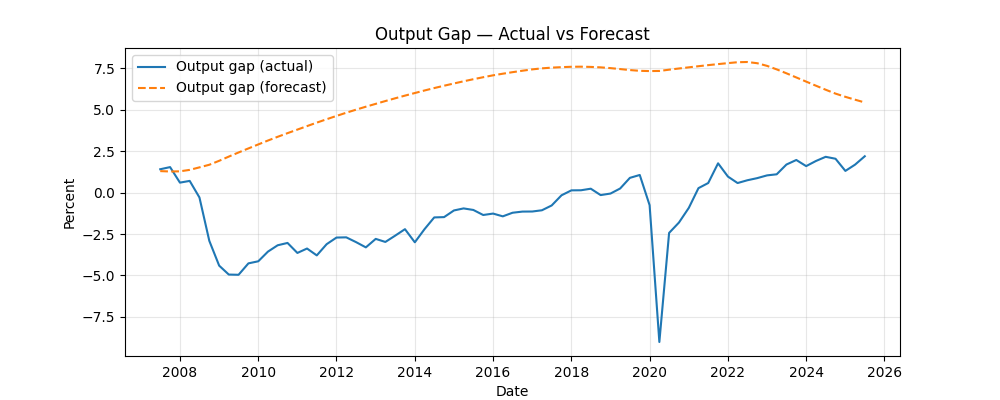

In [ ]:
sub = df_all.loc["2007Q3":]

# Output gap
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(sub.index.to_timestamp(), sub["y"], label="Output gap (actual)")
ax.plot(sub.index.to_timestamp(), sub["y_hat"], "--", label="Output gap (forecast)")
ax.set_title("Output Gap — Actual vs Forecast")
ax.set_xlabel("Date")
ax.set_ylabel("Percent")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

# Save figures for later use
figure_five = fig

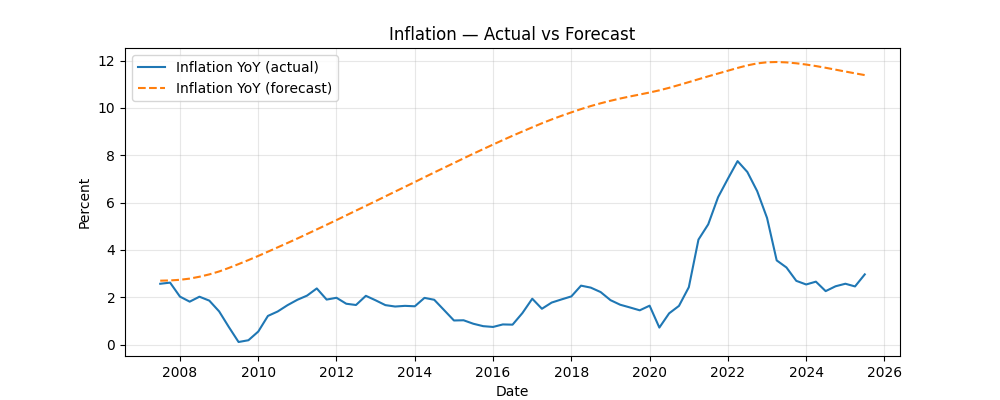

In [255]:
# Inflation
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(sub.index.to_timestamp(), sub["pi"], label="Inflation YoY (actual)")
ax.plot(sub.index.to_timestamp(), sub["pi_hat"], "--", label="Inflation YoY (forecast)")
ax.set_title("Inflation — Actual vs Forecast")
ax.set_xlabel("Date")
ax.set_ylabel("Percent")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

# Save figures for later use
figure_six = fig

## Additional SVAR Output (In Sample Data Range)

In [256]:
# Training window (paper window)
df_train = df.loc["1987Q3":"2007Q2"].copy()

# Predict on the exact in-sample design matrices
y_fit  = svar.mod_y.predict(svar.X_y)
pi_fit = svar.mod_pi.predict(svar.X_pi)

# Sanity: indexes should match design matrices you trained on
assert y_fit.index.equals(svar.X_y.index)
assert pi_fit.index.equals(svar.X_pi.index)

# Build aligned frame on the training index
fit_df = pd.DataFrame(index=df_train.index)
fit_df["y_actual"]  = df_train["y"]
fit_df["pi_actual"] = df_train["pi"]
fit_df["y_fit"]     = y_fit.reindex(fit_df.index)
fit_df["pi_fit"]    = pi_fit.reindex(fit_df.index)

# Residuals (in-sample)
resid_y  = (fit_df["y_actual"]  - fit_df["y_fit"])
resid_pi = (fit_df["pi_actual"] - fit_df["pi_fit"])

# Squared errors
fit_df["se_y_svar"]  = resid_y**2
fit_df["se_pi_svar"] = resid_pi**2

# Drop rows without a fitted value (initial lags)
fit_df = fit_df.dropna(subset=["y_fit","pi_fit"])

# Quick diagnostics
print(fit_df[["se_y_svar","se_pi_svar"]].head())
print("In-sample std(resid):",
      round(resid_y.dropna().std(), 3),
      round(resid_pi.dropna().std(), 3))

        se_y_svar  se_pi_svar
date                         
1988Q1   0.018819    0.000604
1988Q2   0.410345    0.119382
1988Q3   0.001621    0.103834
1988Q4   0.577012    0.002397
1989Q1   0.236579    0.067581
In-sample std(resid): 0.472 0.179


### Figure 4 Output Gap Fit: Squared Errors (Replication)

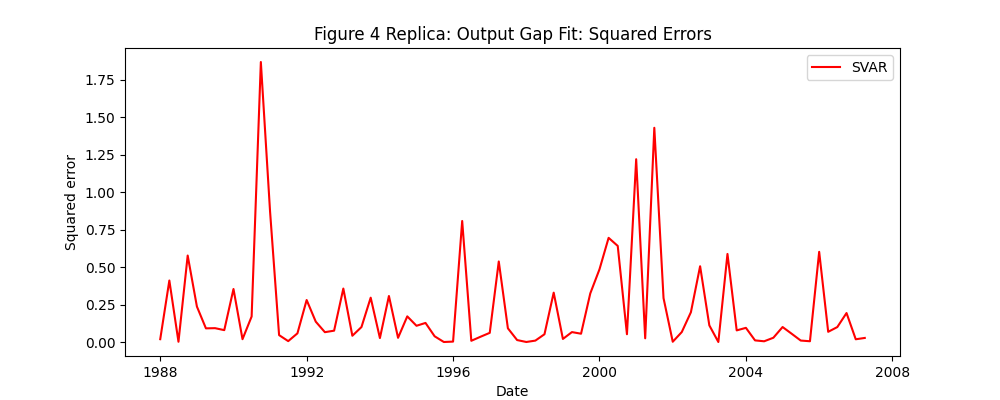

In [262]:
# Figure 4: Output gap fit — squared errors
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(fit_df.index.to_timestamp(), fit_df["se_y_svar"], color="red", label="SVAR", linewidth=1.5)
ax.set_title("Figure 4 Replica: Output Gap Fit: Squared Errors")
ax.set_xlabel("Date"); ax.set_ylabel("Squared error"); ax.grid(False)
ax.legend()
plt.show()

# Save figures for later use
figure_seven = fig

### Figure 5 Inflation Fit: Squared Errors (Replication)

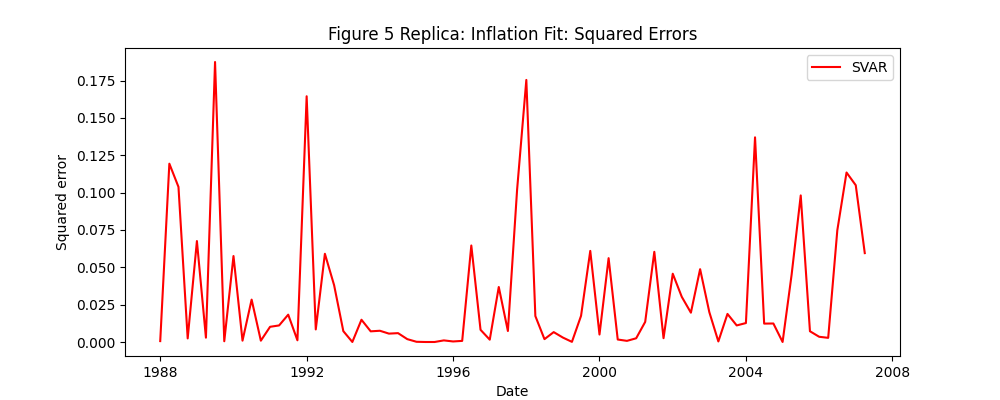

In [263]:
# Figure 5: Inflation fit — squared errors
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(fit_df.index.to_timestamp(), fit_df["se_pi_svar"], color="red", label="SVAR", linewidth=1.5)
ax.set_title("Figure 5 Replica: Inflation Fit: Squared Errors")
ax.set_xlabel("Date"); ax.set_ylabel("Squared error"); ax.grid(False)
ax.legend()
plt.show()

# Save figures for later use
figure_eight = fig

Note: The y-axis scale is different from the paper due to our model using the correct units (YoY percent, not decimals). In addition The smaller squared errors reflect a tighter fit in the replication relative to the Bundesbank baseline

--------

# Citations

1. The pandas development team. pandas-dev/pandas: Pandas [Computer software]. https://doi.org/10.5281/zenodo.3509134

2. Sunder, N. (2025). fedfred: A Python client for the Federal Reserve Economic Database (FRED) API (Version 2.1.5) [Computer software]. https://doi.org/10.5281/zenodo.17180397

3. Harris, C. R., Millman, K. J., van der Walt, S. J., Gommers, R., Virtanen, P., Cournapeau, D., Wieser, E., Taylor, J., Berg, S., Smith, N. J., Kern, R., Picus, M., Hoyer, S., van Kerkwijk, M. H., Brett, M., Haldane, A., Fernández del Río, J., Wiebe, M., Peterson, P., Gérard-Marchant, P., Sheppard, K., Reddy, T., Weckesser, W., Abbasi, H., Gohlke, C., & Oliphant, T. E. (2020). Array programming with NumPy. Nature, 585(7825), 357–362. https://doi.org/10.1038/s41586-020-2649-2

4. Skipper, S., & Josef, P. (2010). statsmodels: Econometric and statistical modeling with python. 9th Python in Science Conference

5. Python Software Foundation. (2025). Python (Version 3.13.7) [Computer software]. Python Software Foundation. https://www.python.org/

6. Hunter, J. D. (2007). Matplotlib: A 2D graphics environment. Computing in Science & Engineering, 9(3), 90–95. https://doi.org/10.1109/MCSE.2007.55

7. Hinterlang, N., & Tänzer, A. (2021). Optimal monetary policy using reinforcement learning. Deutsche Bundesbank. https://books.google.com/books?id=yjjIzgEACAAJ
